<h1>Capstone Project: The Impact of Weather on Flight Delays</h1>

<h2> Notebook 2 - Test dataset</h2> 

<h2>1. Load & Explore Data</h2>

<h3>1.1. Load Data</h3>

In [3]:
# Data files sourced from BTS (see data/README.md)
# Paths reference local directory structure used during development
# Update paths to match your local setup if reproducing

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from matplotlib.colors import LinearSegmentedColormap

from datetime import datetime
import meteostat as ms

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')


In [5]:
# Set colour palette
palette = [
    "#4FA3C5",  # Glacier Lake Blue
    "#2E4259",  # Andean Slate
    "#7E9B6C",  # Moss Trail Green
    "#C7A76C",  # Autumn Grass
    "#D08159",  # Sunset Clay
    "#C9C5E0"   # Frost Lavender
]

sns.set_theme(
    style="whitegrid",
    rc={
        "axes.facecolor": "#F9FAFB",
        "grid.color": "#E6E6E6",
        "figure.facecolor": "white",
        "axes.edgecolor": "#DDDDDD",
        "font.size": 12,
        "axes.titlepad": 12,
        "axes.labelpad": 8,
        "axes.titleweight": "bold",
    }
)

sns.set_palette(palette)

In [6]:
# Read CSVs

jan_25 = pd.read_csv('data/T_ONTIME_REPORTING_01_2025.csv')

feb_25 = pd.read_csv('data/T_ONTIME_REPORTING_02_2025.csv')

march_25 = pd.read_csv('data/T_ONTIME_REPORTING_03_2025.csv')

april_25 = pd.read_csv('data/T_ONTIME_REPORTING_04_2025.csv')

may_25 = pd.read_csv('data/T_ONTIME_REPORTING_05_2025.csv')

june_25 = pd.read_csv('data/T_ONTIME_REPORTING_06_2025.csv')

july_25 = pd.read_csv('data/T_ONTIME_REPORTING_07_2025.csv')

aug_25 = pd.read_csv('data/T_ONTIME_REPORTING_08_2025.csv')

sep_25 = pd.read_csv('data/T_ONTIME_REPORTING_09_2025.csv')

oct_25 = pd.read_csv('data/T_ONTIME_REPORTING_10_2025.csv')

In [7]:
# Check cvs'shapes
print(jan_25.shape)
print(feb_25.shape)
print(march_25.shape)
print(april_25.shape)
print(may_25.shape)
print(june_25.shape)
print(july_25.shape)
print(aug_25.shape)
print(sep_25.shape)
print(oct_25.shape)

(48797, 17)
(46025, 17)
(51525, 17)
(51650, 17)
(52476, 17)
(51696, 17)
(54182, 17)
(53234, 17)
(50372, 17)
(53402, 17)


In [8]:
# Spot check csv
june_25.head()

,FL_DATE,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN,DEST_AIRPORT_ID,DEST,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,CANCELLED,DIVERTED,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY
0,6/1/2025 12:00:00 AM,NaN,3355,12391,ISP,15304,TPA,1405,NaN,NaN,1.0,0.0,NaN,NaN,NaN,NaN,NaN
1,6/1/2025 12:00:00 AM,NaN,3545,12478,JFK,14843,SJU,1129,NaN,NaN,1.0,0.0,NaN,NaN,NaN,NaN,NaN
2,6/1/2025 12:00:00 AM,NaN,408,13577,MYR,10257,ALB,1052,NaN,NaN,1.0,0.0,NaN,NaN,NaN,NaN,NaN
3,6/1/2025 12:00:00 AM,NaN,413,10257,ALB,13577,MYR,1339,NaN,NaN,1.0,0.0,NaN,NaN,NaN,NaN,NaN
4,6/1/2025 12:00:00 AM,195NV,2126,14025,PBG,11697,FLL,1009,1007.0,-2.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN


In [9]:
# Spot check csv
oct_25.head()

,FL_DATE,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN,DEST_AIRPORT_ID,DEST,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,CANCELLED,DIVERTED,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY
0,10/1/2025 12:00:00 AM,192NV,2980,15096,SYR,14986,SRQ,1345,1343.0,-2.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
1,10/1/2025 12:00:00 AM,192NV,3009,14986,SRQ,15096,SYR,1000,942.0,-18.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
2,10/1/2025 12:00:00 AM,814NV,1215,14761,SFB,11537,ELM,610,558.0,-12.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
3,10/1/2025 12:00:00 AM,814NV,2866,11537,ELM,14761,SFB,929,916.0,-13.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
4,10/1/2025 12:00:00 AM,N101DU,2376,12953,LGA,10721,BOS,659,652.0,-7.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN


In [10]:
# Spot check csv
aug_25.head()

,FL_DATE,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN,DEST_AIRPORT_ID,DEST,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,CANCELLED,DIVERTED,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY
0,8/1/2025 12:00:00 AM,NaN,1682,13577,MYR,12391,ISP,2113,NaN,NaN,1.0,0.0,NaN,NaN,NaN,NaN,NaN
1,8/1/2025 12:00:00 AM,NaN,4393,12953,LGA,11278,DCA,600,NaN,NaN,1.0,0.0,NaN,NaN,NaN,NaN,NaN
2,8/1/2025 12:00:00 AM,NaN,4538,12478,JFK,11278,DCA,630,NaN,NaN,1.0,0.0,NaN,NaN,NaN,NaN,NaN
3,8/1/2025 12:00:00 AM,NaN,4817,12478,JFK,10397,ATL,620,NaN,NaN,1.0,0.0,NaN,NaN,NaN,NaN,NaN
4,8/1/2025 12:00:00 AM,205NV,184,15070,SWF,13577,MYR,1836,1824.0,-12.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN


In [11]:
# Merge all datasets
df = pd.concat(
    [jan_25, feb_25, march_25, april_25, may_25, june_25, july_25, aug_25, sep_25, oct_25], axis=0, ignore_index=True)

In [12]:
# Shape
df.shape

(513359, 17)

In [13]:
# Head
df.head()

,FL_DATE,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN,DEST_AIRPORT_ID,DEST,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,CANCELLED,DIVERTED,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY
0,1/1/2025 12:00:00 AM,188NV,501,11697,FLL,14025,PBG,1000,955.0,-5.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
1,1/1/2025 12:00:00 AM,188NV,531,14025,PBG,11697,FLL,1409,1406.0,-3.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
2,1/1/2025 12:00:00 AM,189NV,1062,14025,PBG,14112,PIE,1448,1513.0,25.0,0.0,0.0,0.0,7.0,8.0,0.0,18.0
3,1/1/2025 12:00:00 AM,189NV,2724,14112,PIE,14025,PBG,1100,1059.0,-1.0,0.0,0.0,0.0,0.0,18.0,0.0,0.0
4,1/1/2025 12:00:00 AM,205NV,3009,14986,SRQ,15096,SYR,1000,944.0,-16.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN


In [14]:
df.sample(7)

,FL_DATE,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN,DEST_AIRPORT_ID,DEST,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,CANCELLED,DIVERTED,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY
491524,10/19/2025 12:00:00 AM,N393DA,758,11292,DEN,12478,JFK,2359,10.0,11.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
32979,1/22/2025 12:00:00 AM,N117AN,255,12478,JFK,12892,LAX,800,755.0,-5.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
200739,5/2/2025 12:00:00 AM,N445YX,4727,15096,SYR,13930,ORD,1636,1638.0,2.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
393119,8/22/2025 12:00:00 AM,N243JQ,5694,14122,PIT,12953,LGA,1239,1238.0,-1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
333865,7/19/2025 12:00:00 AM,N203JQ,5607,10994,CHS,12953,LGA,1031,1242.0,131.0,0.0,0.0,119.0,0.0,0.0,0.0,0.0
313605,7/7/2025 12:00:00 AM,N723PS,5501,11278,DCA,10257,ALB,1510,1507.0,-3.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
510378,10/30/2025 12:00:00 AM,N3058J,374,15096,SYR,10721,BOS,600,551.0,-9.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN


In [15]:
# Limit the dataset to JFK only
df = df[df['ORIGIN'] == 'JFK'].copy()

<h3>2.2. Explore and Clean the Data</h3>

In [16]:
#replace spaces in the column names with an underscore
df.columns = [d.replace(' ', '_') for d in df.columns.str.lower()] 

In [17]:
df.columns.tolist()

['fl_date',
 'tail_num',
 'op_carrier_fl_num',
 'origin_airport_id',
 'origin',
 'dest_airport_id',
 'dest',
 'crs_dep_time',
 'dep_time',
 'dep_delay',
 'cancelled',
 'diverted',
 'carrier_delay',
 'weather_delay',
 'nas_delay',
 'security_delay',
 'late_aircraft_delay']

In [18]:
# Assign a new list of column names for more context on what's in them
df = df.rename(columns={
    'fl_date': 'flight_date',
    'fl_date': 'flight_date'
})

In [19]:
# Check results
df.columns.tolist()

['flight_date',
 'tail_num',
 'op_carrier_fl_num',
 'origin_airport_id',
 'origin',
 'dest_airport_id',
 'dest',
 'crs_dep_time',
 'dep_time',
 'dep_delay',
 'cancelled',
 'diverted',
 'carrier_delay',
 'weather_delay',
 'nas_delay',
 'security_delay',
 'late_aircraft_delay']

In [20]:
# Data Types
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 87278 entries, 16 to 513357
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   flight_date          87278 non-null  object 
 1   tail_num             87242 non-null  object 
 2   op_carrier_fl_num    87278 non-null  int64  
 3   origin_airport_id    87278 non-null  int64  
 4   origin               87278 non-null  object 
 5   dest_airport_id      87278 non-null  int64  
 6   dest                 87278 non-null  object 
 7   crs_dep_time         87278 non-null  int64  
 8   dep_time             85925 non-null  float64
 9   dep_delay            85924 non-null  float64
 10  cancelled            87278 non-null  float64
 11  diverted             87278 non-null  float64
 12  carrier_delay        20512 non-null  float64
 13  weather_delay        20512 non-null  float64
 14  nas_delay            20512 non-null  float64
 15  security_delay       20512 non-null  fl

In [21]:
# Check if the dep_delay column has correct values
df.iloc[:, 7:].sample(10)

,crs_dep_time,dep_time,dep_delay,cancelled,diverted,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
176192,1544,1605.0,21.0,0.0,0.0,10.0,0.0,7.0,0.0,11.0
410981,800,743.0,-17.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
153153,1605,1605.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
504472,1830,1836.0,6.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
211548,758,753.0,-5.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
325225,2245,NaN,NaN,1.0,0.0,NaN,NaN,NaN,NaN,NaN
92522,501,455.0,-6.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
152987,705,711.0,6.0,0.0,0.0,6.0,0.0,35.0,0.0,0.0
50557,1030,1034.0,4.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
474385,650,647.0,-3.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN


In [22]:
# Count the number of unique values in a DataFrame or Series. 
# we can identify the continuous and categorical columns in the data
df.nunique() 

flight_date             304
tail_num               2463
op_carrier_fl_num       837
origin_airport_id         1
origin                    1
dest_airport_id          71
dest                     71
crs_dep_time            658
dep_time               1324
dep_delay               613
cancelled                 2
diverted                  2
carrier_delay           438
weather_delay           199
nas_delay               308
security_delay           55
late_aircraft_delay     389
dtype: int64

In [23]:
# Check Null Values
df.isnull().sum()

flight_date                0
tail_num                  36
op_carrier_fl_num          0
origin_airport_id          0
origin                     0
dest_airport_id            0
dest                       0
crs_dep_time               0
dep_time                1353
dep_delay               1354
cancelled                  0
diverted                   0
carrier_delay          66766
weather_delay          66766
nas_delay              66766
security_delay         66766
late_aircraft_delay    66766
dtype: int64

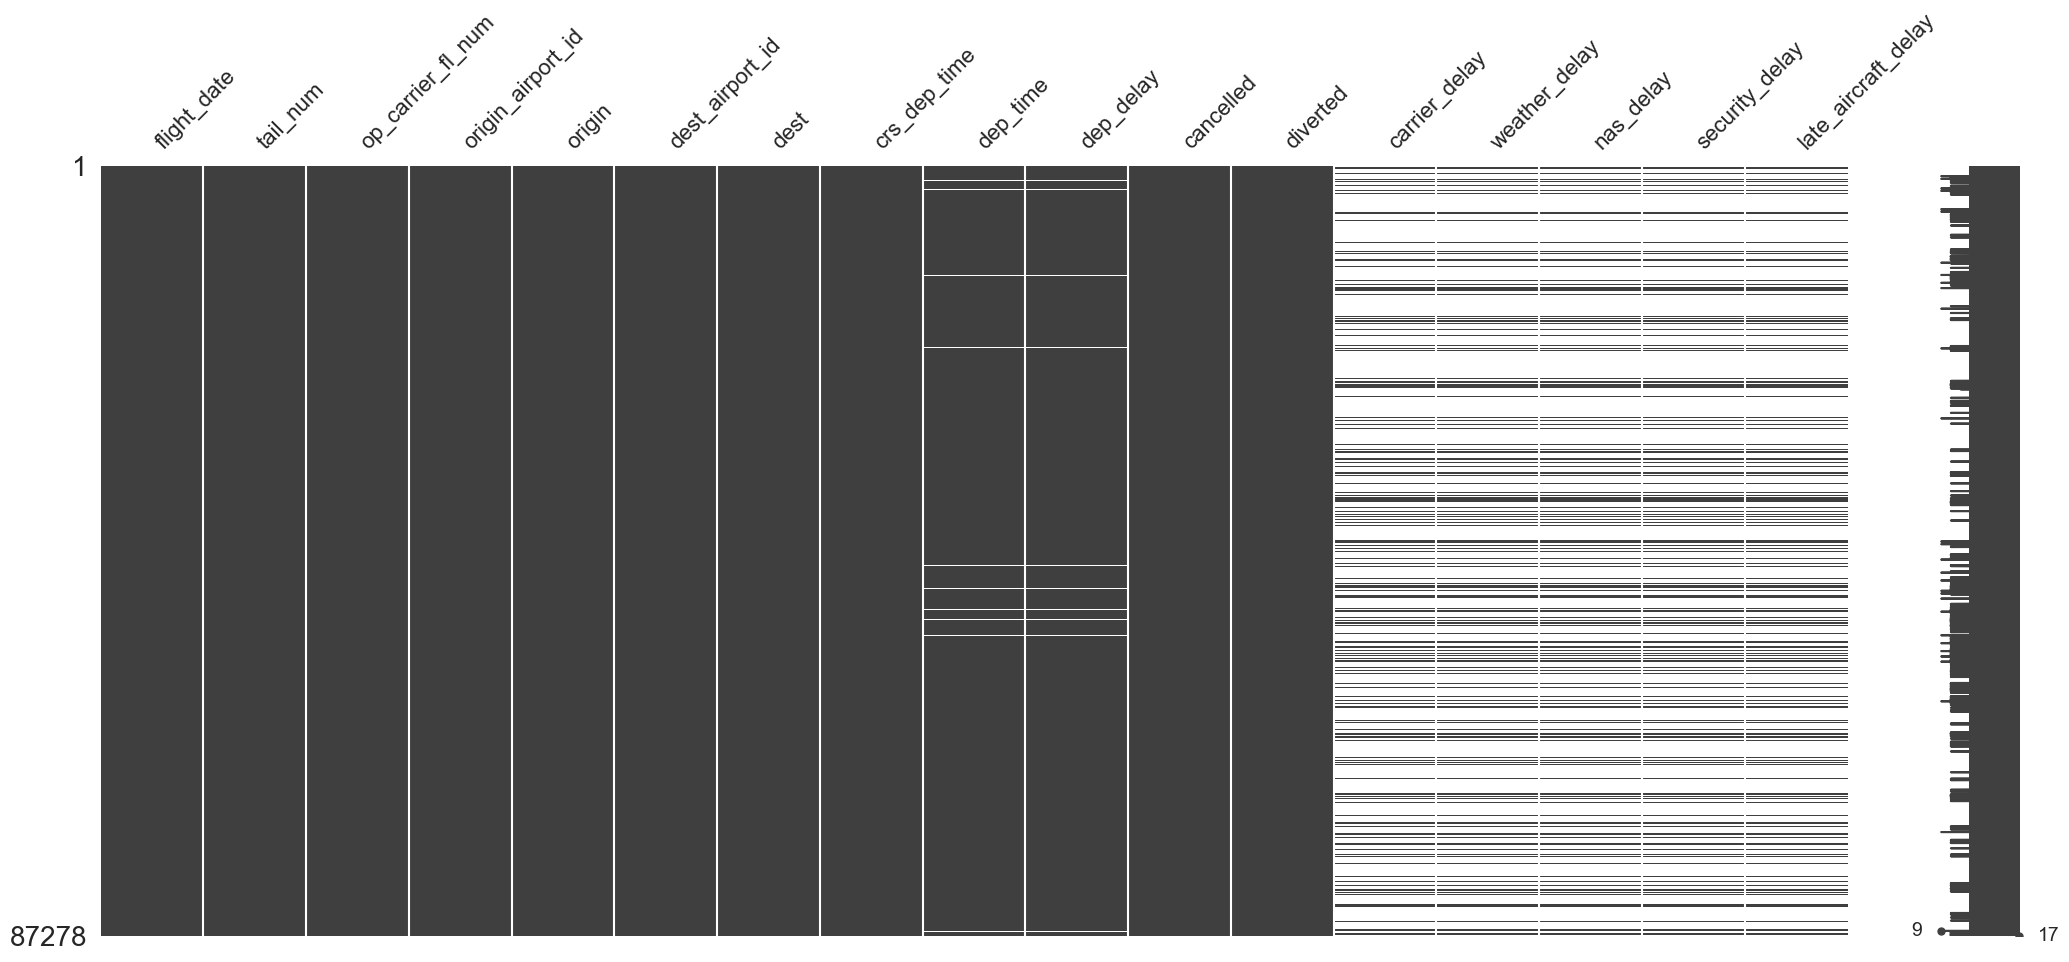

In [24]:
# Check Null Values
msno.matrix(df)
plt.show()

In [25]:
df['carrier_delay'] = df['carrier_delay'].fillna(0) # Replaces all NaNs with 0
df['weather_delay'] = df['weather_delay'].fillna(0) # Replaces all NaNs with 0
df['nas_delay'] = df['nas_delay'].fillna(0) # Replaces all NaNs with 0
df['security_delay'] = df['security_delay'].fillna(0) # Replaces all NaNs with 0
df['late_aircraft_delay'] = df['late_aircraft_delay'].fillna(0) # Replaces all NaNs with 0

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 87278 entries, 16 to 513357
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   flight_date          87278 non-null  object 
 1   tail_num             87242 non-null  object 
 2   op_carrier_fl_num    87278 non-null  int64  
 3   origin_airport_id    87278 non-null  int64  
 4   origin               87278 non-null  object 
 5   dest_airport_id      87278 non-null  int64  
 6   dest                 87278 non-null  object 
 7   crs_dep_time         87278 non-null  int64  
 8   dep_time             85925 non-null  float64
 9   dep_delay            85924 non-null  float64
 10  cancelled            87278 non-null  float64
 11  diverted             87278 non-null  float64
 12  carrier_delay        87278 non-null  float64
 13  weather_delay        87278 non-null  float64
 14  nas_delay            87278 non-null  float64
 15  security_delay       87278 non-null  fl

In [27]:
# Check for NaN values
df.isna().sum()

flight_date               0
tail_num                 36
op_carrier_fl_num         0
origin_airport_id         0
origin                    0
dest_airport_id           0
dest                      0
crs_dep_time              0
dep_time               1353
dep_delay              1354
cancelled                 0
diverted                  0
carrier_delay             0
weather_delay             0
nas_delay                 0
security_delay            0
late_aircraft_delay       0
dtype: int64

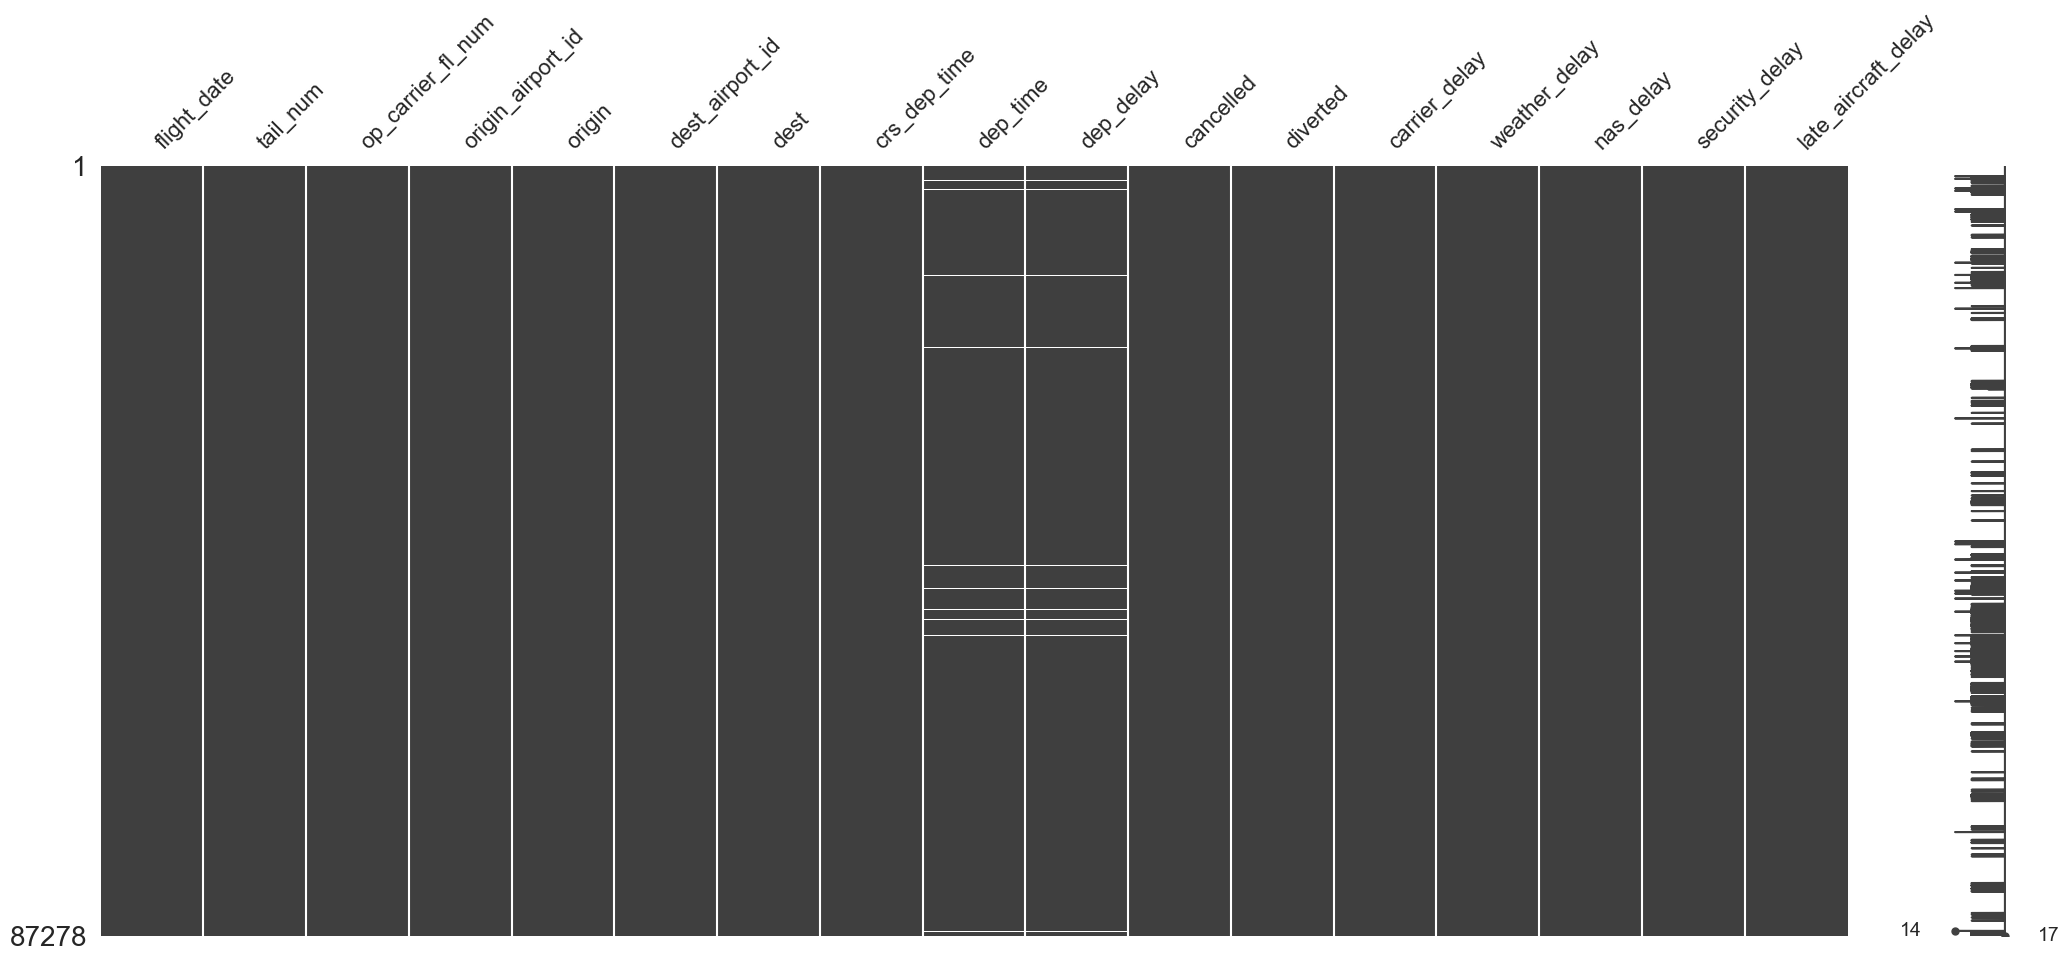

In [28]:
msno.matrix(df)
plt.show()

In [29]:
# Drop rows with any NaN value since these are departure information, cannot impute that
df = df.dropna()

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 85924 entries, 16 to 513357
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   flight_date          85924 non-null  object 
 1   tail_num             85924 non-null  object 
 2   op_carrier_fl_num    85924 non-null  int64  
 3   origin_airport_id    85924 non-null  int64  
 4   origin               85924 non-null  object 
 5   dest_airport_id      85924 non-null  int64  
 6   dest                 85924 non-null  object 
 7   crs_dep_time         85924 non-null  int64  
 8   dep_time             85924 non-null  float64
 9   dep_delay            85924 non-null  float64
 10  cancelled            85924 non-null  float64
 11  diverted             85924 non-null  float64
 12  carrier_delay        85924 non-null  float64
 13  weather_delay        85924 non-null  float64
 14  nas_delay            85924 non-null  float64
 15  security_delay       85924 non-null  fl

In [31]:
# Fix the  dep_time  column type
df['dep_time'] = df['dep_time'].astype('float64')
df['dep_time'] = df['dep_time'].astype('int64')

In [32]:
# Fix the dep_delay column type
df['dep_delay'] = df['dep_delay'].astype('int64')

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 85924 entries, 16 to 513357
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   flight_date          85924 non-null  object 
 1   tail_num             85924 non-null  object 
 2   op_carrier_fl_num    85924 non-null  int64  
 3   origin_airport_id    85924 non-null  int64  
 4   origin               85924 non-null  object 
 5   dest_airport_id      85924 non-null  int64  
 6   dest                 85924 non-null  object 
 7   crs_dep_time         85924 non-null  int64  
 8   dep_time             85924 non-null  int64  
 9   dep_delay            85924 non-null  int64  
 10  cancelled            85924 non-null  float64
 11  diverted             85924 non-null  float64
 12  carrier_delay        85924 non-null  float64
 13  weather_delay        85924 non-null  float64
 14  nas_delay            85924 non-null  float64
 15  security_delay       85924 non-null  fl

In [34]:
# Check the percentage of cancelled flights
df['cancelled'].value_counts(normalize=True)

cancelled
0.0    0.998115
1.0    0.001885
Name: proportion, dtype: float64

In [35]:
# Check the percentage of diverted flights
df['diverted'].value_counts(normalize=True)

diverted
0.0    0.997184
1.0    0.002816
Name: proportion, dtype: float64

In [36]:
df.nlargest(5, 'dep_delay')

,flight_date,tail_num,op_carrier_fl_num,origin_airport_id,origin,dest_airport_id,dest,crs_dep_time,dep_time,dep_delay,cancelled,diverted,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
122782,3/17/2025 12:00:00 AM,N9018E,720,12478,JFK,11503,EGE,725,702,1417,0.0,0.0,671.0,0.0,16.0,0.0,746.0
481073,10/13/2025 12:00:00 AM,N341FR,3545,12478,JFK,14843,SJU,1130,1036,1386,0.0,0.0,66.0,0.0,45.0,0.0,1320.0
329405,7/16/2025 12:00:00 AM,N705FR,1809,12478,JFK,13303,MIA,1244,1042,1318,0.0,0.0,1316.0,0.0,0.0,0.0,0.0
447633,9/23/2025 12:00:00 AM,N645FR,2503,12478,JFK,12892,LAX,1131,850,1279,0.0,0.0,0.0,0.0,0.0,0.0,1269.0
223707,5/16/2025 12:00:00 AM,N109NN,2459,12478,JFK,14908,SNA,937,606,1229,0.0,0.0,1211.0,0.0,0.0,0.0,0.0


In [37]:
df.nlargest(5, 'weather_delay')

,flight_date,tail_num,op_carrier_fl_num,origin_airport_id,origin,dest_airport_id,dest,crs_dep_time,dep_time,dep_delay,cancelled,diverted,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
60145,2/8/2025 12:00:00 AM,N237JQ,5741,12478,JFK,14122,PIT,2029,1240,971,0.0,0.0,0.0,971.0,71.0,0.0,0.0
28295,1/19/2025 12:00:00 AM,N188DN,707,12478,JFK,12892,LAX,1945,825,760,0.0,0.0,0.0,760.0,13.0,0.0,0.0
224046,5/16/2025 12:00:00 AM,N238JQ,5801,12478,JFK,11278,DCA,2100,1254,954,0.0,0.0,42.0,724.0,0.0,0.0,167.0
511100,10/30/2025 12:00:00 AM,N705FR,1511,12478,JFK,11298,DFW,1305,122,737,0.0,0.0,51.0,686.0,10.0,0.0,0.0
60095,2/8/2025 12:00:00 AM,N215JQ,5658,12478,JFK,11066,CMH,2029,749,680,0.0,0.0,0.0,680.0,66.0,0.0,0.0


In [38]:
df["cancelled"].value_counts()

cancelled
0.0    85762
1.0      162
Name: count, dtype: int64

In [39]:
df["diverted"].value_counts()

diverted
0.0    85682
1.0      242
Name: count, dtype: int64

In [40]:
# Drop cancelled and diverted flights (for now)
df = df[(df["cancelled"] == 0) & (df["diverted"] == 0)].copy()

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 85520 entries, 16 to 513357
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   flight_date          85520 non-null  object 
 1   tail_num             85520 non-null  object 
 2   op_carrier_fl_num    85520 non-null  int64  
 3   origin_airport_id    85520 non-null  int64  
 4   origin               85520 non-null  object 
 5   dest_airport_id      85520 non-null  int64  
 6   dest                 85520 non-null  object 
 7   crs_dep_time         85520 non-null  int64  
 8   dep_time             85520 non-null  int64  
 9   dep_delay            85520 non-null  int64  
 10  cancelled            85520 non-null  float64
 11  diverted             85520 non-null  float64
 12  carrier_delay        85520 non-null  float64
 13  weather_delay        85520 non-null  float64
 14  nas_delay            85520 non-null  float64
 15  security_delay       85520 non-null  fl

<b>Observations:</b>
- The dataset is a combination of individual csvs, filtered to JFK.
- Fairly clean column names, renamed ‘flight_date’ column and some data types
- Identified the null values and approached them in various ways: some were filled with 0 where possible, others dropped

<h3>2.3. Add Weather Data</h3>

In [42]:
# Ensure fl_date is string
df['flight_date'] = df['flight_date'].astype(str)

In [43]:
# convert 1347 → "13:47"
df["crs_dep_time"] = df["crs_dep_time"].astype(str).str.zfill(4)
df["dep_time"] = df["dep_time"].astype(str).str.zfill(4)

In [44]:
# Helper to build datetime from date + HHMM string
def build_datetime(date_col, time_col):
    return pd.to_datetime(
        df[date_col] + " " +
        df[time_col].str.slice(0, 2) + ":" +
        df[time_col].str.slice(2, 4),
        errors="coerce"
    )

In [45]:
# Create scheduled departure datetimes (local airport time) - for weather
df["scheduled_dep_dt"] = build_datetime("flight_date", "crs_dep_time")

In [46]:
# Check the date and time have been merged correctly
df[["flight_date", "crs_dep_time", "scheduled_dep_dt"]].sample(5)

,flight_date,crs_dep_time,scheduled_dep_dt
214018,5/10/2025 12:00:00 AM,1900,2025-05-10 19:00:00
210464,5/8/2025 12:00:00 AM,0840,2025-05-08 08:40:00
201468,5/2/2025 12:00:00 AM,0735,2025-05-02 07:35:00
179323,4/20/2025 12:00:00 AM,1329,2025-04-20 13:29:00
438062,9/17/2025 12:00:00 AM,0815,2025-09-17 08:15:00


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 85520 entries, 16 to 513357
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   flight_date          85520 non-null  object        
 1   tail_num             85520 non-null  object        
 2   op_carrier_fl_num    85520 non-null  int64         
 3   origin_airport_id    85520 non-null  int64         
 4   origin               85520 non-null  object        
 5   dest_airport_id      85520 non-null  int64         
 6   dest                 85520 non-null  object        
 7   crs_dep_time         85520 non-null  object        
 8   dep_time             85520 non-null  object        
 9   dep_delay            85520 non-null  int64         
 10  cancelled            85520 non-null  float64       
 11  diverted             85520 non-null  float64       
 12  carrier_delay        85520 non-null  float64       
 13  weather_delay        85520 non-nul

In [48]:
# 1. Make sure sched_dep_dt exists and looks sane
print(df['scheduled_dep_dt'].min(), df['scheduled_dep_dt'].max())

2025-01-01 05:01:00 2025-10-31 22:59:00


In [49]:
2 # Define the station ID
station_id = '74486' #John F. Kennedy International Airport (JFK)

# Convert start/end to plain Python datetimes (not pandas Timestamps)
start = df["scheduled_dep_dt"].min().to_pydatetime()
end   = df["scheduled_dep_dt"].max().to_pydatetime()

print("Start:", start, "End:", end)

Start: 2025-01-01 05:01:00 End: 2025-10-31 22:59:00


In [50]:
# 3. Fetch daily weather data
weather_data = ms.hourly(station_id, start, end)
weather_data = weather_data.fetch()

In [51]:
# 4. Display the first few rows of the DataFrame
if not weather_data.empty:
    print(weather_data.sample(10))
else:
    print("No data found for the specified station and time period.")

                     temp  rhum  prcp  snwd  wdir  wspd  wpgt    pres  tsun  \
time                                                                          
2025-07-22 07:00:00  21.1    61   0.0  <NA>    20  13.0  <NA>  1017.3  <NA>   
2025-05-27 16:00:00  21.1    55   0.0  <NA>   190  18.4  <NA>  1027.8  <NA>   
2025-09-24 01:00:00  22.0    87   0.0  <NA>   200  17.0  <NA>  1016.0  <NA>   
2025-06-22 00:00:00  24.4    69   0.0  <NA>   190  25.9  <NA>  1018.7  <NA>   
2025-04-13 05:00:00   4.4    86  <NA>  <NA>   360  20.5  <NA>  1013.4  <NA>   
2025-04-03 20:00:00  13.3    86   0.0  <NA>   190  20.5  <NA>  1016.0  <NA>   
2025-10-31 22:00:00  13.0    42   0.0  <NA>   270  37.0  33.0  1000.0  <NA>   
2025-01-25 11:00:00  -6.1    65   0.0  <NA>   260   9.4  <NA>  1026.8  <NA>   
2025-09-19 23:00:00  26.0    42   0.0  <NA>   320  13.0  <NA>  1016.0  <NA>   
2025-03-31 04:00:00   8.3    93   0.3  <NA>    90  13.0  <NA>  1014.5  <NA>   

                     cldc  coco  
time             

In [52]:
#5 Reset index so 'time' becomes a column
weather_data = weather_data.reset_index().rename(columns={"time": "weather_time"})

In [53]:
#6 Sort both
df = df.sort_values('scheduled_dep_dt')
weather_data = weather_data.sort_values('weather_time')

In [54]:
#7 Merge the weather data with the flights data on scheduled departure time and date column
merged_df = pd.merge_asof(
    df,
    weather_data,
    left_on='scheduled_dep_dt',
    right_on='weather_time',
    direction='nearest',
    tolerance=pd.Timedelta('1h')
)

In [55]:
merged_df.shape

(85520, 30)

In [56]:
# Removes rows where the weather join failed
merged_df = merged_df.dropna(subset=['weather_time']).copy()

In [57]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85520 entries, 0 to 85519
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   flight_date          85520 non-null  object        
 1   tail_num             85520 non-null  object        
 2   op_carrier_fl_num    85520 non-null  int64         
 3   origin_airport_id    85520 non-null  int64         
 4   origin               85520 non-null  object        
 5   dest_airport_id      85520 non-null  int64         
 6   dest                 85520 non-null  object        
 7   crs_dep_time         85520 non-null  object        
 8   dep_time             85520 non-null  object        
 9   dep_delay            85520 non-null  int64         
 10  cancelled            85520 non-null  float64       
 11  diverted             85520 non-null  float64       
 12  carrier_delay        85520 non-null  float64       
 13  weather_delay        85520 non-

In [58]:
merged_df[merged_df['flight_date'] == '6/24/2025 12:00:00 AM']['temp'].value_counts()

temp
25.6    59
36.7    35
38.9    33
37.2    31
25.0    28
33.9    25
30.0    20
35.6    19
32.2    15
34.4    13
26.1     8
31.7     2
Name: count, dtype: Int64

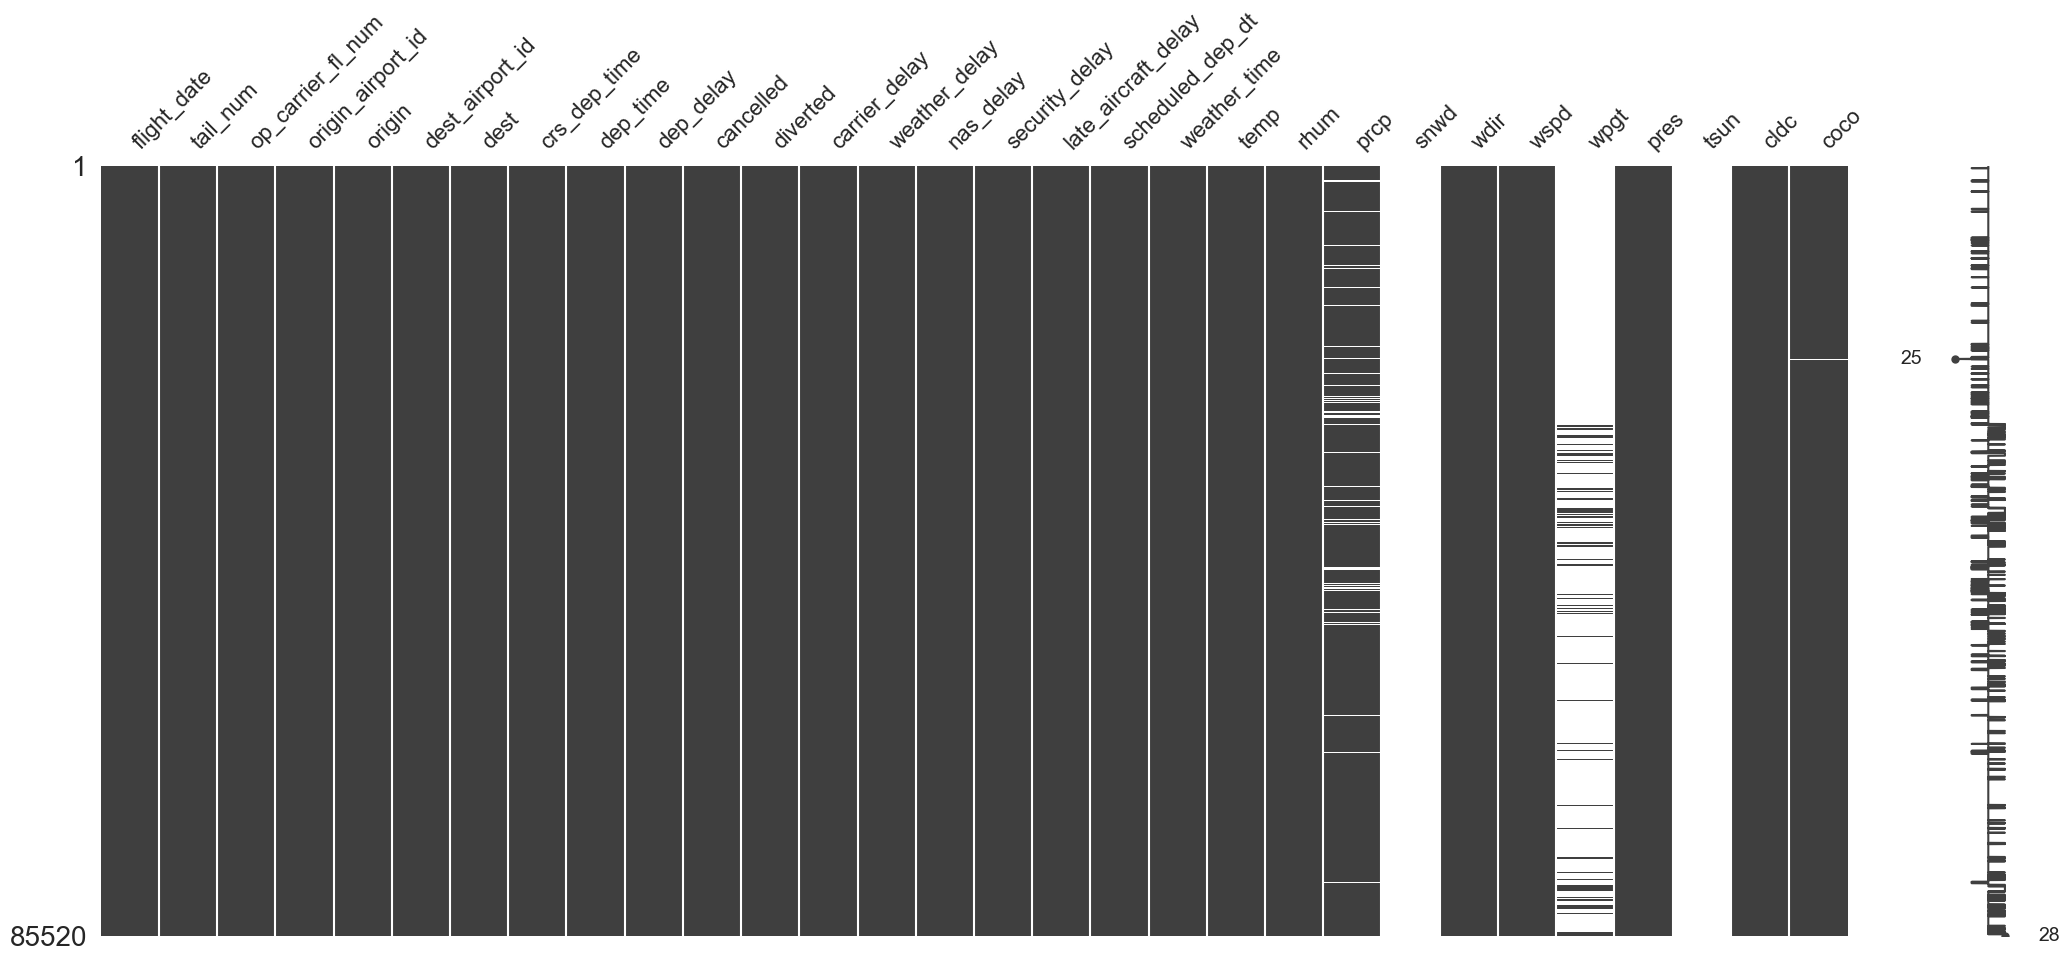

In [59]:
# Check Null Values
msno.matrix(merged_df)
plt.show()

In [60]:
# Merge quality check - how far off is the matched weather to the scheduled departure time
(merged_df['scheduled_dep_dt'] - merged_df['weather_time']).abs().describe()

count                        85520
mean     0 days 00:13:59.792329279
std      0 days 00:11:36.636419791
min                0 days 00:00:00
25%                0 days 00:01:00
50%                0 days 00:14:00
75%                0 days 00:25:00
max                0 days 00:59:00
dtype: object

<b>Observations: </b>
- Most flights are matched within ~15 minutes of weather data.
- Worst case is 59 minutes.
- Match has gone well 

<h3>2.4. Clean Weather Data</h3>

In [61]:
# Separate the weather data and check what's in it
cols = [
    'temp', 
    'rhum',
    'prcp',
    'snwd',
    'wdir',
    'wspd',
    'wpgt',
    'pres',
    'tsun',
    'cldc',
    'coco'
]

In [62]:
for col in merged_df[cols]:
    print(col, ': ', merged_df[col].unique(), '\n')

temp :  <FloatingArray>
[ 8.9,  7.2,  8.3,  7.8,  9.4, 11.7, 10.6, 11.1,  5.0,  4.4,
 ...
 24.0, 16.0, 14.0, 13.0, 12.0, 11.0,  9.0,  8.0,  6.0,  7.0]
Length: 111, dtype: Float64 

rhum :  <IntegerArray>
[ 89,  93,  90,  86,  71,  68,  61,  65,  60,  56,  53,  57,  55,  62,  50,
  48,  46,  43,  41,  37,  38,  36,  42,  44,  52,  49,  54,  51,  47,  45,
  39,  33,  34,  35,  32,  40,  58,  76,  78,  81,  69,  31,  64,  59,  88,
  82,  75,  72,  70,  66,  67,  63,  73,  74,  85,  79,  27,  30,  29,  28,
  92,  80,  25,  96,  97,  26,  22,  23,  24,  77,  21,  83,  20,  19, 100,
  18,  87,  84,  94,  91]
Length: 80, dtype: UInt8 

prcp :  <FloatingArray>
[ 0.0, <NA>,  0.3,  0.8,  0.5,  2.0,  1.0,  1.5,  1.3,  1.8,  2.3,  2.8,  6.4,
  6.9,  2.5,  4.1,  3.6,  4.3,  3.8,  3.0,  3.3,  0.2,  5.1,  6.6,  8.9,  6.1,
 13.0,  4.6, 10.7,  5.8,  2.2,  1.4,  0.4,  2.4,  4.5,  0.7,  0.1,  0.9,  4.0,
  1.1,  3.5,  0.6,  4.2,  5.5]
Length: 44, dtype: Float64 

snwd :  <IntegerArray>
[<NA>]
Length: 1, d

COCO - Weather Condition Codes
Hourly weather data may include information on the observed weather condition. Please note that the weather condition is not a key parameter for Meteostat. METAR reports, issued by weather stations located at airports, only report significant weather events. Also, some weather stations do not provide weather condition data at all.

<a href="https://dev.meteostat.net/formats.html" >More information on Coco</a>

<a href="https://dev.meteostat.net/parameters" >More information on Meteorological Parameters</a>

In [63]:
# 'snwd', 'wpgt' and 'tsun' is empty so can drop it
columns_to_drop = ['snwd', 'wpgt', 'tsun']
merged_df.drop(columns=columns_to_drop, axis=1, inplace=True)
merged_df.head()

,flight_date,tail_num,op_carrier_fl_num,origin_airport_id,origin,dest_airport_id,dest,crs_dep_time,dep_time,dep_delay,...,scheduled_dep_dt,weather_time,temp,rhum,prcp,wdir,wspd,pres,cldc,coco
0,1/1/2025 12:00:00 AM,N559JB,1683,12478,JFK,13204,MCO,0501,0459,-2,...,2025-01-01 05:01:00,2025-01-01 06:00:00,8.9,89,0.0,90,7.6,998.2,6,8
1,1/1/2025 12:00:00 AM,N2044J,713,12478,JFK,11697,FLL,0501,0500,-1,...,2025-01-01 05:01:00,2025-01-01 06:00:00,8.9,89,0.0,90,7.6,998.2,6,8
2,1/1/2025 12:00:00 AM,N324RN,655,12478,JFK,13303,MIA,0525,0523,-2,...,2025-01-01 05:25:00,2025-01-01 06:00:00,8.9,89,0.0,90,7.6,998.2,6,8
3,1/1/2025 12:00:00 AM,N4022J,523,12478,JFK,12892,LAX,0545,0541,-4,...,2025-01-01 05:45:00,2025-01-01 06:00:00,8.9,89,0.0,90,7.6,998.2,6,8
4,1/1/2025 12:00:00 AM,N615FR,3547,12478,JFK,14843,SJU,0600,0605,5,...,2025-01-01 06:00:00,2025-01-01 06:00:00,8.9,89,0.0,90,7.6,998.2,6,8


In [64]:
# Check for NaN values
merged_df.isna().sum()

flight_date               0
tail_num                  0
op_carrier_fl_num         0
origin_airport_id         0
origin                    0
dest_airport_id           0
dest                      0
crs_dep_time              0
dep_time                  0
dep_delay                 0
cancelled                 0
diverted                  0
carrier_delay             0
weather_delay             0
nas_delay                 0
security_delay            0
late_aircraft_delay       0
scheduled_dep_dt          0
weather_time              0
temp                      0
rhum                      0
prcp                   5118
wdir                      0
wspd                      0
pres                      0
cldc                      0
coco                     85
dtype: int64

In [65]:
# filling missing Total Precipitation data
merged_df['prcp'] = merged_df['prcp'].fillna(0)

In [66]:
# Filling missing data cloud cover with a median but add a flag it was imputed
merged_df['cldc_missing'] = merged_df['cldc'].isna().astype(int)

merged_df['cldc'] = merged_df['cldc'].fillna(
    merged_df['cldc'].median()
)

In [67]:
# Drop rows with any NaN value since these are departure information, cannot impute that
merged_df = merged_df.dropna()

In [68]:
# Check for NaN values
merged_df.isna().sum()

flight_date            0
tail_num               0
op_carrier_fl_num      0
origin_airport_id      0
origin                 0
dest_airport_id        0
dest                   0
crs_dep_time           0
dep_time               0
dep_delay              0
cancelled              0
diverted               0
carrier_delay          0
weather_delay          0
nas_delay              0
security_delay         0
late_aircraft_delay    0
scheduled_dep_dt       0
weather_time           0
temp                   0
rhum                   0
prcp                   0
wdir                   0
wspd                   0
pres                   0
cldc                   0
coco                   0
cldc_missing           0
dtype: int64

Since The United States Federal Aviation Administration (FAA) considers a flight to be delayed when it is 15 minutes later than its scheduled time, we will create a new column with 0 for no delay and 1 for delay when  dep_delay is over 15 mins 

In [69]:
# Create a new column with 0 for no delay and 1 for delay when delayed over 15 mins 
merged_df['delayed_15'] = (merged_df['dep_delay'] >= 15).astype(int)

In [70]:
# Check how it came across
merged_df.sample(5)


,flight_date,tail_num,op_carrier_fl_num,origin_airport_id,origin,dest_airport_id,dest,crs_dep_time,dep_time,dep_delay,...,temp,rhum,prcp,wdir,wspd,pres,cldc,coco,cldc_missing,delayed_15
57843,7/26/2025 12:00:00 AM,N986JB,615,12478,JFK,14771,SFO,1959,2031,32,...,26.7,49,0.0,120,18.4,1019.8,2,3,0,1
3830,1/15/2025 12:00:00 AM,N223JQ,5618,12478,JFK,12451,JAX,0740,0744,4,...,-3.9,46,0.0,300,33.5,1018.0,2,4,0,0
61894,8/10/2025 12:00:00 AM,N989JT,411,12478,JFK,12889,LAS,0630,0624,-6,...,20.0,65,0.0,250,11.2,1024.0,0,2,0,0
41638,5/30/2025 12:00:00 AM,N111ZM,15,12478,JFK,14771,SFO,1700,1708,8,...,21.1,78,0.0,180,18.4,1004.8,4,4,0,0
82070,10/19/2025 12:00:00 AM,N843DN,1643,12478,JFK,10423,AUS,1359,1402,3,...,19.0,73,0.0,170,32.0,1016.0,4,2,0,0


In [71]:
# Check what is the proportion of delayed flights after data clean
merged_df['delayed_15'].value_counts(normalize=True)*100

delayed_15
0    79.716744
1    20.283256
Name: proportion, dtype: float64

<b>Observations:</b>
- created a ‘scheduled departure time’ column that combined the flight date with scheduled departure time columns and the values in the new column are in the datetime64[ns] format.
- added meteorological data in using Meteostat Python library based on the scheduled departure time, hourly, for station_id = '74486' #John F. Kennedy International Airport (JFK). Most flights are matched within  approx. 15 minutes of weather data, with the worst case being 59 minutes for the train set
- dropped any rows with missing weather data, then checked the null values and dropped  'snwd', and 'wpgt' since there were unfortunately no observations in these columns. This test dataset did include ‘wpgt’ observations, Peak Wind Gust data, but since the train and test data should have the same predictor columns for consistency of the model’s performance and the train data did not contain this information, the Peak Wind Gust data data was removed from the test model. 
- In terms of any missing weather related values:
    - ‘prcp’ was missing 5118, fill with a 0
    - for the ‘cldc’, we created a new column indicating data was missing, then filled the missing data with the median of ‘cldc’
- Once the data was cleaned, we created our target variable column, ‘delayed_15’, based on the ‘departure delay’ column, by assigning 1 for ‘delay’ for those observations where the departure delay is equal or over 15 mins.


<h2>3. Perform Exploratory Data Analysis (EDA)</h2>

In [72]:
merged_df.columns.tolist()

['flight_date',
 'tail_num',
 'op_carrier_fl_num',
 'origin_airport_id',
 'origin',
 'dest_airport_id',
 'dest',
 'crs_dep_time',
 'dep_time',
 'dep_delay',
 'cancelled',
 'diverted',
 'carrier_delay',
 'weather_delay',
 'nas_delay',
 'security_delay',
 'late_aircraft_delay',
 'scheduled_dep_dt',
 'weather_time',
 'temp',
 'rhum',
 'prcp',
 'wdir',
 'wspd',
 'pres',
 'cldc',
 'coco',
 'cldc_missing',
 'delayed_15']

In [73]:
# Separate continuous features for EDA
continuous_features = [
    'temp',
    'rhum',
    'prcp',
    'wspd',
    'pres',
    'dep_delay'
]

In [74]:
# Just weather continious features
weather_features = ['temp', 'rhum', 'prcp', 'wspd', 'pres']

In [75]:
# cloud cover: 0–8 octas. 0 oktas represents the complete absence of cloud. 8 oktas represents full cloud cover with no breaks.
ordinal_features = [
    'cldc' 
]

In [76]:
# Wind direction is not linear
# The average wind direction in degrees (°)
circular_features = [
    'wdir'
]

In [77]:
# a weather condition code, not a magnitude.
categorical_features = [
    'coco'
]

In [78]:
#statistical summary of the DataFrame (Transpose) 
merged_df[continuous_features].describe().T

,count,mean,std,min,25%,50%,75%,max
temp,85435.0,15.035085,9.261925,-10.0,8.3,16.1,22.2,38.9
rhum,85435.0,64.911699,19.848482,18.0,48.0,65.0,83.0,100.0
prcp,85435.0,0.066285,0.457205,0.0,0.0,0.0,0.0,13.0
wspd,85435.0,18.559675,9.644602,0.0,11.2,17.0,24.1,57.6
pres,85435.0,1016.846506,7.233961,983.4,1012.8,1017.0,1021.8,1037.1
dep_delay,85435.0,13.290466,55.571221,-26.0,-6.0,-3.0,8.0,1417.0


In [79]:
# Correlation
merged_df_corr = merged_df[continuous_features].corr(numeric_only=True) 
merged_df_corr

,temp,rhum,prcp,wspd,pres,dep_delay
temp,1.000000,0.162077,-0.017833,-0.189473,-0.044504,0.087566
rhum,0.162077,1.000000,0.186808,-0.412705,-0.176836,0.053520
prcp,-0.017833,0.186808,1.000000,-0.015092,-0.088867,0.043167
wspd,-0.189473,-0.412705,-0.015092,1.000000,-0.273587,0.056171
pres,-0.044504,-0.176836,-0.088867,-0.273587,1.000000,-0.071496
dep_delay,0.087566,0.053520,0.043167,0.056171,-0.071496,1.000000


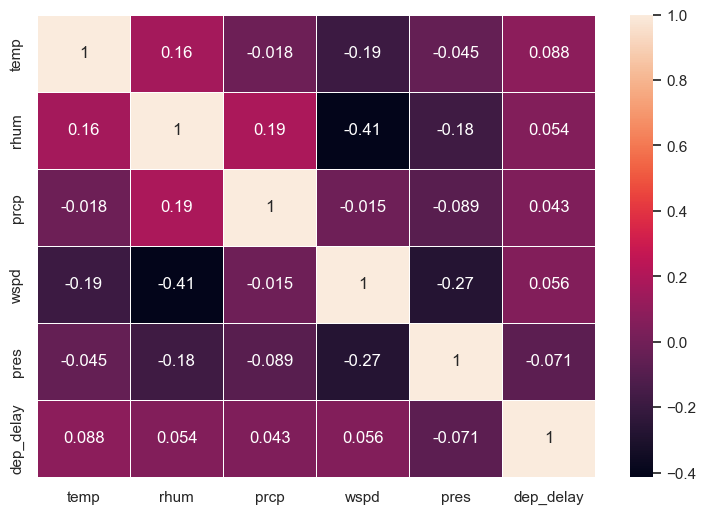

In [80]:
# Create the heatmap
plt.figure(figsize=(9, 6)) # Optional: adjust the size
sns.heatmap(merged_df_corr, annot=True, linewidths=.5) 
plt.show()

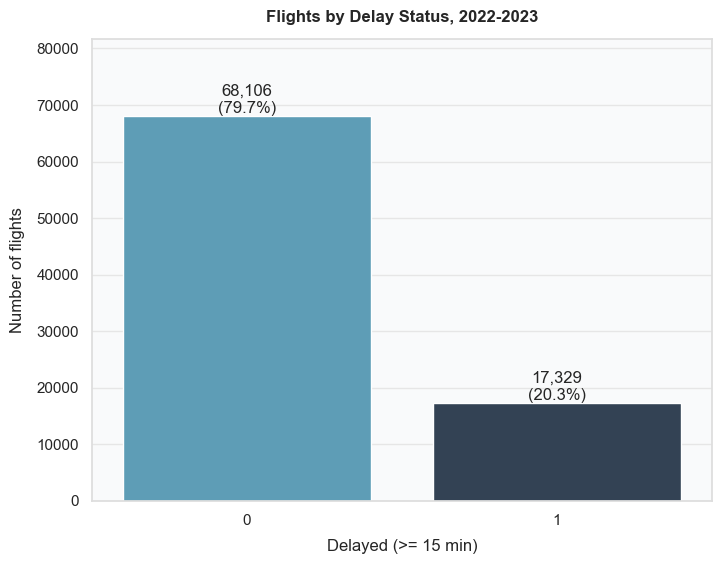

In [81]:
# Plot 'delayed_15'
# 1. Create a sample DataFrame and get value counts
counts = merged_df['delayed_15'].value_counts().sort_index()

plt.figure(figsize=(8,6))
sns.barplot(x=counts.index, y=counts.values,
            palette=[palette[0], palette[1]])

plt.title("Flights by Delay Status, 2022-2023")
plt.xlabel("Delayed (>= 15 min)")
plt.ylabel("Number of flights")
plt.margins(y=0.20)

total = counts.sum()
for i, v in enumerate(counts.values):
    pct = v / total * 100
    plt.text(i, v, f"{v:,}\n({pct:.1f}%)",
             ha='center', va='bottom')

plt.show()

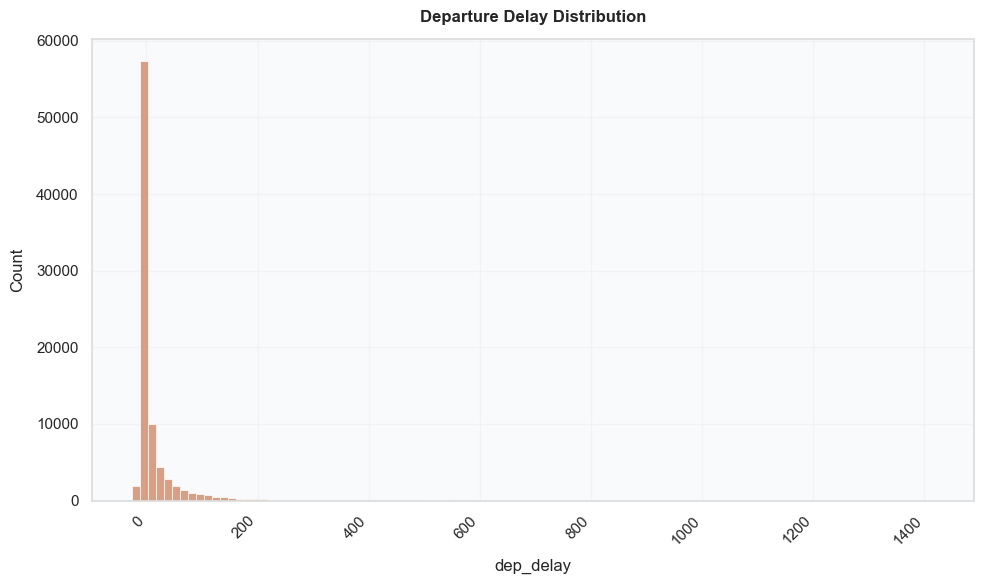

In [82]:
fig = plt.figure(figsize=(10, 6))
sns.histplot(merged_df['dep_delay'], color=palette[4], bins=100)
plt.grid(alpha=0.3) #adds the grid
plt.xticks(rotation=45, ha='right') # Rotates the labels by 45 degrees
plt.title('Departure Delay Distribution')
plt.tight_layout()
plt.show()

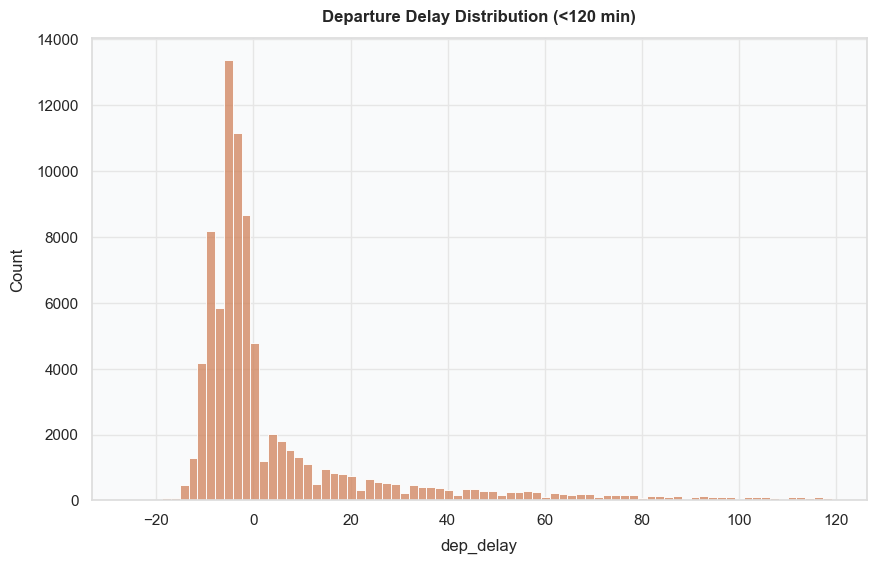

In [83]:
plt.figure(figsize=(10,6))
sns.histplot(
    merged_df.query("dep_delay < 120")['dep_delay'],
    bins=80,
    color=palette[4]
)
plt.title("Departure Delay Distribution (<120 min)")
plt.show()

In [84]:
# summary stats
merged_df['dep_delay'].describe(
    percentiles=[.5, .75, .9, .95, .99]
)

count    85435.000000
mean        13.290466
std         55.571221
min        -26.000000
50%         -3.000000
75%          8.000000
90%         49.000000
95%         95.000000
99%        240.000000
max       1417.000000
Name: dep_delay, dtype: float64

- Median flight leaves slightly early.
- 75% leave within 10 min.
- Extreme tail exists.

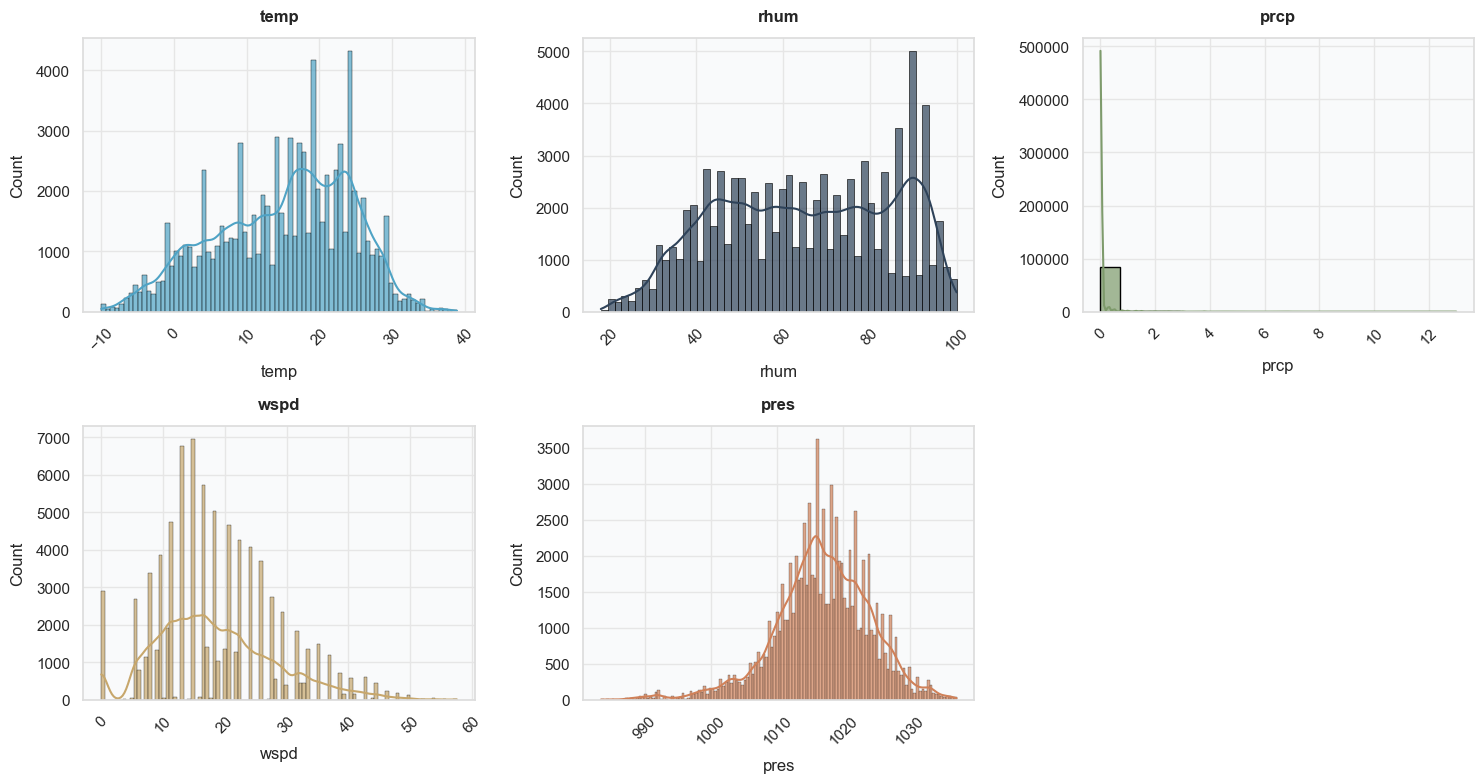

In [85]:
# Plot continuous weather features
n_cols = 3

n_rows = int(np.ceil(len(weather_features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(weather_features):
    color = palette[i % len(palette)]
    
    sns.histplot(
        data=merged_df, 
        x=col, 
        kde=True, 
        ax=axes[i], 
        color=color, 
        alpha=0.7, 
        edgecolor="black"
    )
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

# Remove empty plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

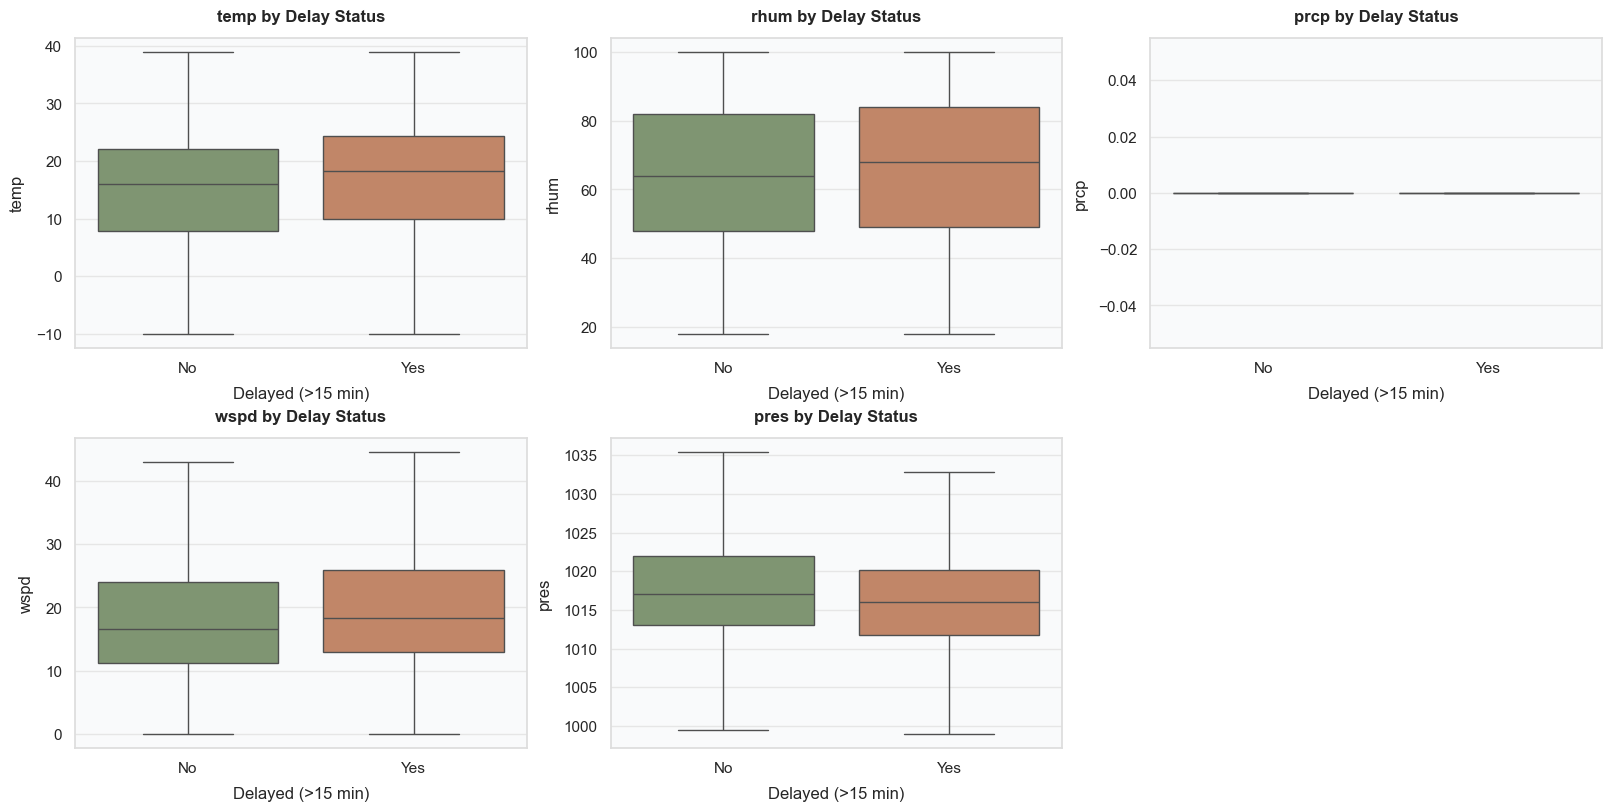

In [86]:
# Box plots with breakdown by class

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(16, 8),
    constrained_layout=True
)

axes = axes.flatten()

for i, feature in enumerate(weather_features):
    sns.boxplot(
        data=merged_df,
        x='delayed_15',
        y=feature,
        #hue='delayed_15',  
        palette=[palette[2], palette[4]],
        ax=axes[i],
        showfliers=False  # important for heavy tails
    )
    axes[i].set_title(f"{feature} by Delay Status")
    axes[i].set_xlabel("Delayed (>15 min)")
    axes[i].set_xticklabels(["No", "Yes"])

# Remove unused subplot
fig.delaxes(axes[-1])

plt.show()

In [87]:

merged_df.groupby('delayed_15')[weather_features].median()

,temp,rhum,prcp,wspd,pres
delayed_15,,,,,
0,16.0,64.0,0.0,16.6,1017.1
1,18.3,68.0,0.0,18.4,1016.0


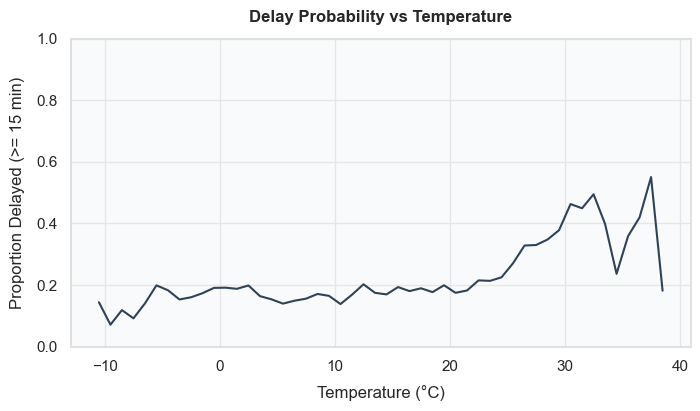

In [88]:
plot_df = merged_df[['temp','delayed_15']].copy()

# 1°C bins (adjust if you want smoother)
plot_df['temp_bin'] = pd.cut(plot_df['temp'], bins=np.arange(-20, 41, 1))

temp_rate = plot_df.groupby('temp_bin', observed=True)['delayed_15'].mean()
temp_mid = [interval.mid for interval in temp_rate.index]

plt.figure(figsize=(8,4))
plt.plot(temp_mid, temp_rate.values, color=palette[1])
plt.title("Delay Probability vs Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("Proportion Delayed (>= 15 min)")
plt.ylim(0, 1)
plt.show()

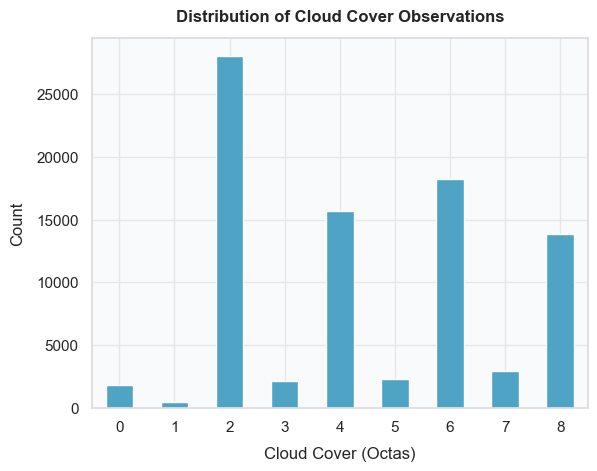

In [89]:
merged_df['cldc'].value_counts().sort_index().plot(kind='bar')
plt.title("Distribution of Cloud Cover Observations")
plt.xlabel("Cloud Cover (Octas)")
plt.ylabel("Count")
plt.xticks(rotation=0, ha='center') # ha='center' (default) or 'right' can be used
plt.show()

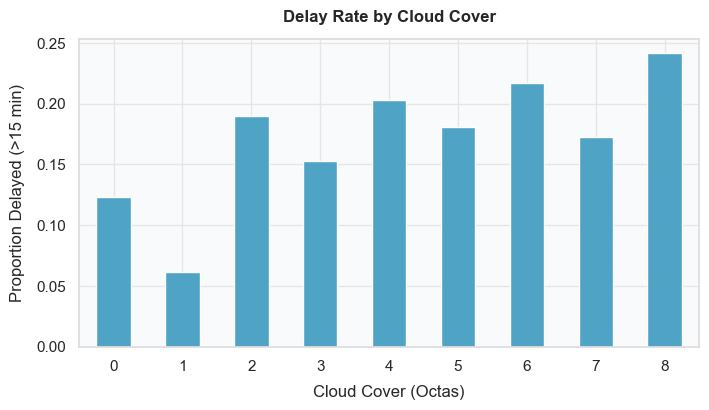

In [90]:
cldc_delay = (
    merged_df
    .groupby('cldc')['delayed_15']
    .mean()
)
cldc_delay.plot(kind='bar', figsize=(8,4))
plt.ylabel("Proportion Delayed (>15 min)")
plt.xlabel("Cloud Cover (Octas)")
plt.xticks(rotation=0, ha='center') # ha='center' (default) or 'right' can be used
plt.title("Delay Rate by Cloud Cover")
plt.show()

In [91]:
#Bin wind direction into compass sectors
merged_df['wdir_bin_eda'] = pd.cut(
    merged_df['wdir'],
    bins=[-0.1,45,90,135,180,225,270,315,360],
    labels=['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'],
    include_lowest=True
)

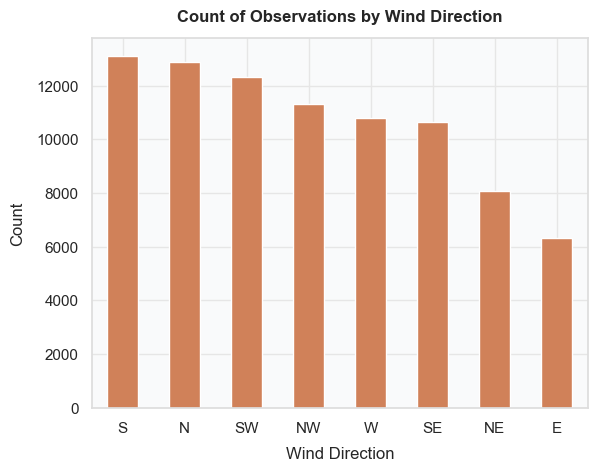

In [92]:
merged_df['wdir_bin_eda'].value_counts().plot(kind='bar', color=palette[4])
plt.title("Count of Observations by Wind Direction")
plt.xlabel("Wind Direction")
plt.ylabel("Count")
plt.xticks(rotation=0, ha='center') # ha='center' (default) or 'right' can be used
plt.show()

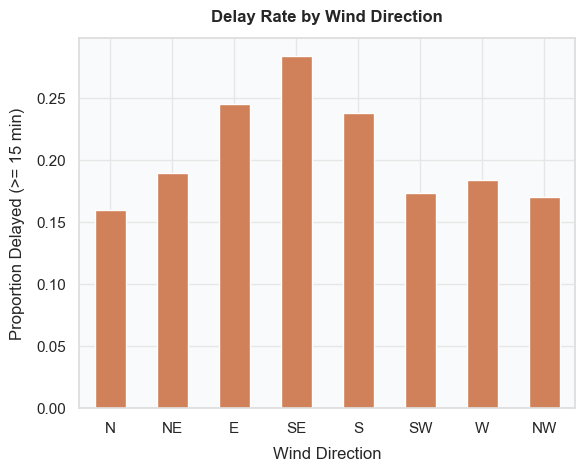

In [93]:
merged_df.groupby('wdir_bin_eda')['delayed_15'].mean().plot(kind='bar', color=palette[4])
plt.ylabel("Proportion Delayed (>= 15 min)")
plt.xlabel("Wind Direction")
plt.title("Delay Rate by Wind Direction")
plt.xticks(rotation=0, ha='center') # ha='center' (default) or 'right' can be used
plt.show()

In [94]:
# Create the mapping dictionary for coco
weather_labels = {
    1:"Clear", 2:"Fair", 3:"Cloudy", 4:"Overcast",
    5:"Fog", 6:"Freezing Fog",
    7:"Light Rain", 8:"Rain", 9:"Heavy Rain",
    10:"Freezing Rain", 11:"Heavy Freezing Rain",
    12:"Sleet", 13:"Heavy Sleet",
    14:"Light Snowfall", 15:"Snowfall", 16:"Heavy Snowfall",
    17:"Rain Shower", 18:"Heavy Rain Shower",
    19:"Sleet Shower", 20:"Heavy Sleet Shower",
    21:"Snow Shower", 22:"Heavy Snow Shower",
    23:"Lightning", 24:"Hail",
    25:"Thunderstorm", 26:"Heavy Thunderstorm",
    27:"Storm"
}

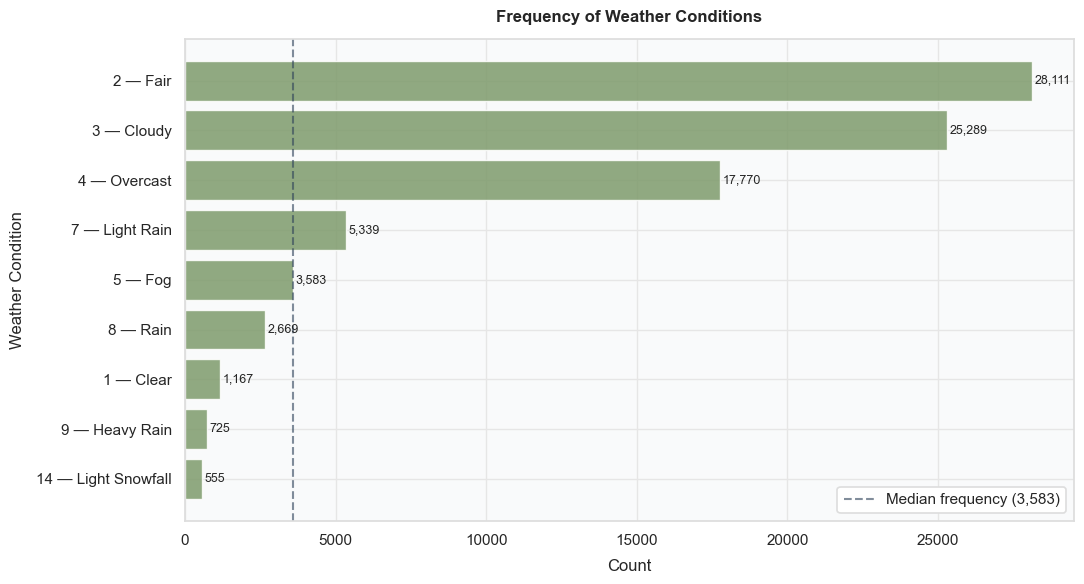

In [95]:
# Build labelled counts

min_n = 500

freq_df = (
    merged_df['coco']
    .value_counts()
    .sort_values()   # ascending for barh
    .rename("count")
    .to_frame()
    .assign(
        weather_label=lambda d:
        d.index.astype(str) + " — " + d.index.map(weather_labels)
    )
)

freq_df = freq_df[freq_df['count'] >= min_n]

plt.figure(figsize=(11,6))

bars = plt.barh(
    freq_df['weather_label'],
    freq_df['count'],
    color=palette[2],
    alpha=0.85
)

plt.title("Frequency of Weather Conditions")
plt.xlabel("Count")
plt.ylabel("Weather Condition")

# annotate counts
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + freq_df['count'].max() * 0.003,
        bar.get_y() + bar.get_height()/2,
        f"{int(width):,}",
        va='center',
        fontsize=9
    )

median_count = freq_df['count'].median()

plt.axvline(
    median_count,
    linestyle='--',
    linewidth=1.5,
    color='#2E4259',
    alpha=0.6,
    label=f'Median frequency ({int(median_count):,})'
)

legend = plt.legend(
    loc='lower right',
    frameon=True,
    fancybox=True,     # rounded corners
    framealpha=1,      # solid background
    edgecolor='#DDDDDD',
    facecolor='white',
    fontsize=11
)

legend.get_frame().set_linewidth(1.2)


plt.tight_layout()
plt.show()

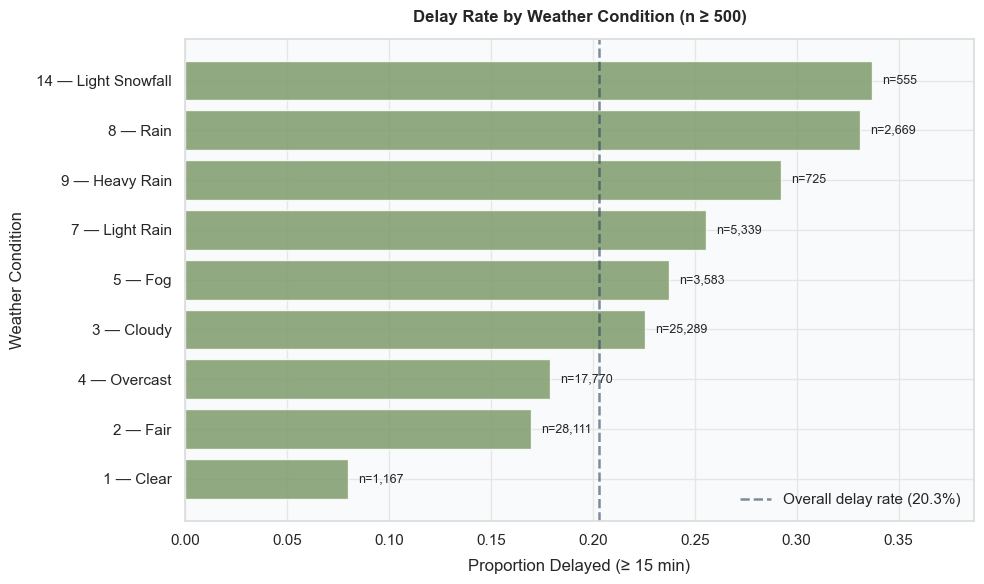

In [96]:
# Assume 'value_to_exclude' is the value you want to drop from the 'coco' column
value_to_exclude = 0

coco_summary = (
    merged_df[merged_df['coco'] != value_to_exclude] # Filter out the value
    .groupby('coco')
    .agg(delay_rate=('delayed_15','mean'),
         n=('delayed_15','size'))
    .sort_values('delay_rate', ascending=False)
)

# Keep top 12 by delay rate but require minimum n
min_n = 500
plot_df = coco_summary[coco_summary['n'] >= min_n].head(12)

# Map labels cleanly
plot_df = plot_df.assign(
    weather_label = plot_df.index.astype(str) + " — " + plot_df.index.map(weather_labels)
)

# Sort so highest delay is at the top
plot_df = plot_df.sort_values("delay_rate")

plt.figure(figsize=(10,6))

bars = plt.barh(
    plot_df['weather_label'],
    plot_df['delay_rate'],
    color=palette[2],
    alpha=0.85
)

plt.xlabel("Proportion Delayed (≥ 15 min)")
plt.ylabel("Weather Condition")
plt.title(f"Delay Rate by Weather Condition (n ≥ {min_n})")

# annotate counts at end of bars
for bar, n in zip(bars, plot_df['n']):
    plt.text(
        bar.get_width() + 0.005,
        bar.get_y() + bar.get_height()/2,
        f"n={int(n):,}",
        va='center',
        fontsize=9
    )

plt.xlim(0, min(1, plot_df['delay_rate'].max() + 0.05))

overall_rate = merged_df['delayed_15'].mean()

# reference line for the overall delay rate
overall_rate = merged_df['delayed_15'].mean()

plt.axvline(
    overall_rate,
    linestyle='--',
    linewidth=1.8,
    color=palette[1],
    alpha=0.6,
    label=f'Overall delay rate ({overall_rate:.1%})'
)

plt.legend(frameon=False)

plt.tight_layout()
plt.show()

In [97]:
merged_df['coco'].describe(
    percentiles=[.5, .75, .9, .95, .99]
)

count     85435.0
mean     3.503845
std      2.009702
min           1.0
50%           3.0
75%           4.0
90%           7.0
95%           7.0
99%           9.0
max          25.0
Name: coco, dtype: Float64

In [98]:
# What is the breakdown of weather code observations over 10?
coco_10 = merged_df[merged_df['coco'] >=10]
coco_10['coco'].value_counts(normalize=True)*100

coco
14    70.971867
15    11.636829
25     9.079284
12     3.836317
18     2.429668
16     1.278772
13     0.767263
Name: proportion, dtype: Float64

In [99]:
merged_df.groupby("coco")["delayed_15"].mean().sort_values()

coco
1     0.079692
18    0.105263
2     0.169507
4     0.178953
16    0.200000
3     0.225355
12    0.233333
5     0.237510
7     0.255666
9     0.292414
8     0.330836
14    0.336937
15    0.384615
25    0.605634
13    0.833333
Name: delayed_15, dtype: float64

<b>Observations:</b>
- The statistical summary performed on the continuous features indicate that various features differ in range greatly, e.g. Total Precipitation ranges from 0 to 13, with the median being 0, whilst Air Pressure (MSL) ranges from 983.4 to 1037.1. Depending on the model, we need to scale our data.
- the proportion of delayed flights in the train dataset is 20.3%
- We can see from the above that there is no drastic difference in average weather conditions between delayed and non-delayed flights. there isn't much change between the cancelled/ non cancelled flights when it comes to average weather conditions. Differences exist but are modest.
- Temperatures range from -10 to 38.9 degrees Celsius. That’s not a mistake, Eastern US experienced a rare June heatwave event in 2025. On June 24 and 25, 2025, JFK Airport recorded 102°F, marking the hottest June day on record for that location. Our data indicates that there could be an increased probability of flights being delayed as the temperature drops or rises.
- flights departing under high cloud cover (7–8 octas) experience an approximately 10–12 percentage-point higher probability of departure delay (>15 minutes) compared to clear-sky conditions.
- probability of departure delay increases with the eastern and south-eastern winds. For our location, JFK, Eastern and north-eastern winds are often associated with coastal systems, storms, nor’easters.
- With the weather conditions code, 99% of observations range from Clear to Heavy Rain. Within the remaining 1% is 70% of the observations are Light Snowfall and we can see that flights departing under this weather code condition, as well as Rain and Heavy Rain , experience a higher probability of departure delay (>15 minutes), compared to other weather conditions.
- The absence of other Weather Condition Codes is most likely linked to the fact that severe weather conditions don’t just cause delays but cancellations.


In [100]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 85435 entries, 0 to 85519
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   flight_date          85435 non-null  object        
 1   tail_num             85435 non-null  object        
 2   op_carrier_fl_num    85435 non-null  int64         
 3   origin_airport_id    85435 non-null  int64         
 4   origin               85435 non-null  object        
 5   dest_airport_id      85435 non-null  int64         
 6   dest                 85435 non-null  object        
 7   crs_dep_time         85435 non-null  object        
 8   dep_time             85435 non-null  object        
 9   dep_delay            85435 non-null  int64         
 10  cancelled            85435 non-null  float64       
 11  diverted             85435 non-null  float64       
 12  carrier_delay        85435 non-null  float64       
 13  weather_delay        85435 non-null 

<h2>4. Prepare the Data and Export</h2>

- Deal with the data as required by the modelling technique
    - **Outliers** (remove or adjust if possible or necessary)
    - **Null** (remove or interpolate if possible or necessary)
    - **Missing Values** (remove or interpolate if possible or necessary)
    - **Coded content** (transform if possible or necessary [str to number or vice-versa])
    - **Feature Engineer** (if useful or necessary)

In [101]:
""" 
Sine and cosine transformations are used to convert angular wind direction data (\(0^{\circ }-360^{\circ }\)) into continuous Cartesian components (U and V). 
This transformation is essential in meteorology and data science to avoid the discontinuity at \(360^{\circ }/0^{\circ }\) (where values are numerically far apart but physically close). 
"""
# sine/cosine transformations for wind direction 
merged_df['wdir_rad'] = np.deg2rad(merged_df['wdir'])
merged_df['wdir_sin'] = np.sin(merged_df['wdir_rad'])
merged_df['wdir_cos'] = np.cos(merged_df['wdir_rad'])

In [102]:
merged_df

,flight_date,tail_num,op_carrier_fl_num,origin_airport_id,origin,dest_airport_id,dest,crs_dep_time,dep_time,dep_delay,...,wspd,pres,cldc,coco,cldc_missing,delayed_15,wdir_bin_eda,wdir_rad,wdir_sin,wdir_cos
0,1/1/2025 12:00:00 AM,N559JB,1683,12478,JFK,13204,MCO,0501,0459,-2,...,7.6,998.2,6,8,0,0,NE,1.570796,1.0,-0.0
1,1/1/2025 12:00:00 AM,N2044J,713,12478,JFK,11697,FLL,0501,0500,-1,...,7.6,998.2,6,8,0,0,NE,1.570796,1.0,-0.0
2,1/1/2025 12:00:00 AM,N324RN,655,12478,JFK,13303,MIA,0525,0523,-2,...,7.6,998.2,6,8,0,0,NE,1.570796,1.0,-0.0
3,1/1/2025 12:00:00 AM,N4022J,523,12478,JFK,12892,LAX,0545,0541,-4,...,7.6,998.2,6,8,0,0,NE,1.570796,1.0,-0.0
4,1/1/2025 12:00:00 AM,N615FR,3547,12478,JFK,14843,SJU,0600,0605,5,...,7.6,998.2,6,8,0,0,NE,1.570796,1.0,-0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85515,10/31/2025 12:00:00 AM,N3149J,486,12478,JFK,14576,ROC,2145,2328,103,...,37.0,1000.0,4,3,0,1,SW,4.712389,-1.0,0.0
85516,10/31/2025 12:00:00 AM,N722TW,1732,12478,JFK,14771,SFO,2155,2156,1,...,37.0,1000.0,4,3,0,0,SW,4.712389,-1.0,0.0
85517,10/31/2025 12:00:00 AM,N2039J,1118,12478,JFK,10721,BOS,2230,2346,76,...,37.0,1000.0,4,3,0,1,SW,4.712389,-1.0,0.0
85518,10/31/2025 12:00:00 AM,N638JB,1128,12478,JFK,14307,PVD,2245,2238,-7,...,37.0,1000.0,4,3,0,0,SW,4.712389,-1.0,0.0


In [103]:
print("cldc missing:", merged_df['cldc'].isna().sum())
print("coco missing:", merged_df['coco'].isna().sum())
print("coco unique min/max:", merged_df['coco'].min(), merged_df['coco'].max())
print(merged_df['coco'].value_counts().head(10)) #0 is now my “Unknown” category; valid codes start at 1.

cldc missing: 0
coco missing: 0
coco unique min/max: 1 25
coco
2     28111
3     25289
4     17770
7      5339
5      3583
8      2669
1      1167
9       725
14      555
15       91
Name: count, dtype: Int64


In [104]:
# Final pre-export sanity checklist
print(merged_df.shape)
print(merged_df.info())

(85435, 33)
<class 'pandas.core.frame.DataFrame'>
Index: 85435 entries, 0 to 85519
Data columns (total 33 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   flight_date          85435 non-null  object        
 1   tail_num             85435 non-null  object        
 2   op_carrier_fl_num    85435 non-null  int64         
 3   origin_airport_id    85435 non-null  int64         
 4   origin               85435 non-null  object        
 5   dest_airport_id      85435 non-null  int64         
 6   dest                 85435 non-null  object        
 7   crs_dep_time         85435 non-null  object        
 8   dep_time             85435 non-null  object        
 9   dep_delay            85435 non-null  int64         
 10  cancelled            85435 non-null  float64       
 11  diverted             85435 non-null  float64       
 12  carrier_delay        85435 non-null  float64       
 13  weather_delay        854

In [106]:
# Export the merged_df for modelling in the another notebook 
merged_df.to_csv("data/merged_df_2025.csv", index=False)